In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path
import matplotlib.pyplot as plt

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.sbeed import (
    SBEEDSolver,
    DiscreteMDPSpec,
    RBFStateFeatures,
    RBFStateActionFeatures,
    TabularStateFeatures,
    SBEEDEvaluator,
)

/home/mauro/anaconda3/envs/fogas/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3grid

In [2]:
def plot_grid_with_rbf(
    grid_size,
    centers,
    variance,
    values=None,
    policy=None,
    goal_grid=None,
    pit_grid=None,
    wall_states=None,
    terminal_states=None,
    title="Grid World with RBF Centers",
):
    """
    Plot a square grid with optional values, policy arrows, RBF centers, and RBF radius.

    Args:
        grid_size: Side length of square grid.
        centers: Tensor/array with shape [K, 2], normalized as [row, col] in [0, 1].
        variance: Scalar or per-center variance. Radius is sqrt(variance).
        values: Optional 1D state values with length grid_size * grid_size.
        policy: Optional [N, A] policy probabilities or [N] best actions.
        goal_grid, pit_grid: Optional special state ids.
        wall_states, terminal_states: Optional sets of state ids.
        title: Plot title.
    """
    centers = torch.as_tensor(centers, dtype=torch.float64)

    if centers.ndim != 2 or centers.shape[1] != 2:
        raise ValueError("centers must have shape [K, 2] as normalized [row, col] coordinates")

    variance = torch.as_tensor(variance, dtype=torch.float64).reshape(-1)
    if variance.numel() == 1:
        variance = variance.repeat(centers.shape[0])
    if variance.numel() != centers.shape[0]:
        raise ValueError("variance must be scalar or have one value per center")

    radius = torch.sqrt(variance)

    N = grid_size * grid_size
    wall_states = set() if wall_states is None else set(wall_states)
    terminal_states = set() if terminal_states is None else set(terminal_states)

    def state_to_pos(s):
        return divmod(int(s), grid_size)

    fig, ax = plt.subplots(figsize=(8, 8))

    grid = np.zeros((grid_size, grid_size))

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values)
        grid = values.reshape(grid_size, grid_size)

    ax.imshow(
        grid,
        cmap="viridis",
        origin="upper",
        alpha=0.3 if values is not None else 0.1,
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=2)

    if policy is not None and hasattr(policy, "detach"):
        policy = policy.detach().cpu().numpy()

    for s in range(N):
        r, c = state_to_pos(s)

        if goal_grid is not None and s == goal_grid:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="green", alpha=0.5))
            ax.text(c, r, "GOAL", ha="center", va="center", fontweight="bold")

        elif pit_grid is not None and s == pit_grid:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="red", alpha=0.5))
            ax.text(c, r, "PIT", ha="center", va="center", fontweight="bold", color="white")

        elif s in wall_states:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="gray"))
            ax.text(c, r, "WALL", ha="center", va="center", fontweight="bold", color="white")

        else:
            ax.text(c - 0.4, r - 0.4, str(s), fontsize=8, color="gray")
            if values is not None:
                ax.text(c, r, f"{values[s]:.2f}", ha="center", va="center", fontsize=10)

        if policy is not None and s not in terminal_states and s not in wall_states:
            if len(policy.shape) == 2:
                best_action = np.argmax(policy[s], axis=-1)
            else:
                best_action = policy[s]

            dx, dy = 0.0, 0.0
            if best_action == 0:
                dy = -0.3
            elif best_action == 1:
                dy = 0.3
            elif best_action == 2:
                dx = -0.3
            elif best_action == 3:
                dx = 0.3

            ax.arrow(c, r, dx, dy, head_width=0.1, head_length=0.1, fc="black", ec="black")

    for i, center in enumerate(centers):
        row_norm, col_norm = center.tolist()

        r = row_norm * (grid_size - 1)
        c = col_norm * (grid_size - 1)
        radius_cells = radius[i].item() * (grid_size - 1)

        circle = plt.Circle(
            (c, r),
            radius_cells,
            color="tab:red",
            fill=False,
            linewidth=2,
            alpha=0.8,
        )
        ax.add_patch(circle)

        ax.scatter(c, r, color="tab:red", marker="x", s=120, linewidths=3)
        ax.text(
            c,
            r + 0.18,
            f"c{i}",
            ha="center",
            va="bottom",
            color="tab:red",
            fontweight="bold",
        )

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(grid_size - 0.5, -0.5)
    plt.show()


In [3]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
goal_grid = 8

def to_rc(s):
    return divmod(int(s), 3)

def to_s(r, c):
    return r * 3 + c

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:
        r = max(0, r - 1)
    elif a == 1:
        r = min(2, r + 1)
    elif a == 2:
        c = max(0, c - 1)
    elif a == 3:
        c = min(2, c + 1)

    return to_s(r, c)


state_coords = torch.tensor(
    [[r / 2.0, c / 2.0] for r in range(3) for c in range(3)],
    dtype=torch.float64,
)

centers = torch.tensor(
    [
        [0.25, 0.25],
        [0.25, 0.75],
        [0.75, 0.25],
        [0.75, 0.75],
    ],
    dtype=torch.float64,
)

value_features = RBFStateFeatures(
    n_states=N,
    centers=centers,
    state_coords=state_coords,
    bandwidth="nearest",
    include_bias=True,
)

rho_features = RBFStateActionFeatures(
    state_features=value_features,
    n_actions=A,
)

policy_features = TabularStateFeatures(n_states=N)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)


def reward_fn(s, a, sp):
    return 1.0 if int(sp) == goal_grid else -0.1

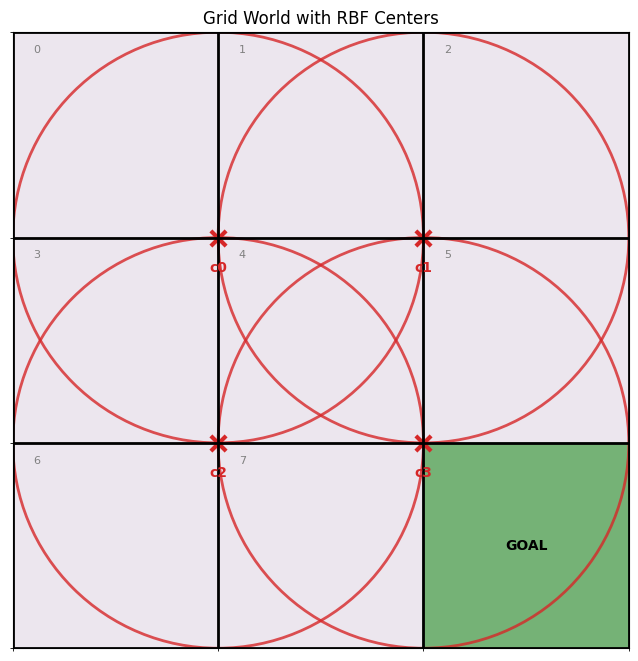

In [4]:
plot_grid_with_rbf(
    grid_size=3,
    centers=centers,
    variance=value_features.variance,
    goal_grid=goal_grid,
    terminal_states={goal_grid},
)

In [6]:
solver_sbeed = SBEEDSolver(
    spec=mdp_spec,
    lambda_entropy=0.01,
    eta=0.01,
    ridge=1e-6,
    lr_value=1e-2,
    lr_policy=1e-2,
    tau=100000.0,
    buffer_mode="fifo",
    max_buffer_size=3000,
    batch_size=64,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=2000,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=50,
    start_state=x_0,
    behavior="policy",
    epsilon=0.1,
    terminal_states={goal_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/2000 buffer=1050 objective=0.034006 primal_mse=0.034396 dual_mse=0.038965 theta_grad=4.802e-02 policy_grad=8.913e-04
episode=100/2000 buffer=2050 objective=0.033355 primal_mse=0.033623 dual_mse=0.026779 theta_grad=1.953e-02 policy_grad=3.261e-04
episode=150/2000 buffer=3000 objective=0.030046 primal_mse=0.031202 dual_mse=0.115595 theta_grad=2.667e-02 policy_grad=6.385e-04
episode=200/2000 buffer=3000 objective=0.029288 primal_mse=0.029655 dual_mse=0.036661 theta_grad=3.519e-02 policy_grad=5.787e-04
episode=250/2000 buffer=3000 objective=0.026932 primal_mse=0.027210 dual_mse=0.027843 theta_grad=2.559e-02 policy_grad=1.623e-04
episode=300/2000 buffer=3000 objective=0.027987 primal_mse=0.028465 dual_mse=0.047779 theta_grad=1.553e-02 policy_grad=3.474e-04
episode=350/2000 buffer=3000 objective=0.026631 primal_mse=0.026882 dual_mse=0.025039 theta_grad=2.552e-02 policy_grad=5.733e-04
episode=400/2000 buffer=3000 objective=0.028341 primal_mse=0.029231 dual_mse=0.088916 theta_grad=4

KeyboardInterrupt: 